# ResNet50 - Conteo de Huevos Aedes
Evaluación de grilla de hiperparámetros

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import json
import cv2
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [36]:
import copy
from copy import deepcopy

# y luego usar: best_state = deepcopy(model.state_dict())


In [16]:
# CARGAR DATOS
def load_split(split_name='train', img_size=(256, 256)):
    json_path = f'{split_name}/_annotations.coco.json'
    with open(json_path, 'r') as f:
        coco = json.load(f)
    
    anns_by_id = {ann['image_id']: [] for ann in coco['annotations']}
    for ann in coco['annotations']:
        anns_by_id[ann['image_id']].append(ann['bbox'])
    
    images, counts = [], []
    for img_info in coco['images']:
        path = f"{split_name}/{img_info['file_name']}"
        img = cv2.imread(path)
        if img is None:
            continue
        
        img = cv2.resize(img, img_size)
        img = img.astype(np.float32) / 255.0
        images.append(img)
        
        count = len(anns_by_id.get(img_info['id'], []))
        counts.append(float(count))
    
    return np.array(images), np.array(counts)

print('Cargando datos...')
X_train, y_train = load_split('train')
X_val, y_val = load_split('valid')
X_test, y_test = load_split('test')

print(f'Train: {X_train.shape}, Valid: {X_val.shape}, Test: {X_test.shape}')
print(f'Conteos - Train: {y_train.min():.0f}-{y_train.max():.0f} (μ={y_train.mean():.1f})')
print(f'Conteos - Valid: {y_val.min():.0f}-{y_val.max():.0f} (μ={y_val.mean():.1f})')
print(f'Conteos - Test:  {y_test.min():.0f}-{y_test.max():.0f} (μ={y_test.mean():.1f})')

Cargando datos...
Train: (1032, 256, 256, 3), Valid: (294, 256, 256, 3), Test: (156, 256, 256, 3)
Conteos - Train: 0-503 (μ=47.7)
Conteos - Valid: 0-543 (μ=55.9)
Conteos - Test:  4-382 (μ=56.0)


In [17]:
# FUNCIONES DE MÉTRICAS
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

def print_metrics(y_true, y_pred, label):
    m = compute_metrics(y_true, y_pred)
    print(f"{label:12} | MAE: {m['MAE']:7.4f} | RMSE: {m['RMSE']:7.4f} | R²: {m['R2']:7.4f}")
    return m

In [18]:
# MODELO RESNET50
def build_resnet50(head_type='H1'):
    model = models.resnet50(pretrained=True)
    for p in model.parameters():
        p.requires_grad = False
    
    if head_type == 'H1':
        model.fc = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )
    elif head_type == 'H2':
        model.fc = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 1)
        )
    elif head_type == 'H3':
        model.fc = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
    
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return model, trainable

def prepare_loaders(X_tr, y_tr, X_va, y_va, X_te, y_te, bs=16):
    X_tr = torch.from_numpy(X_tr).permute(0, 3, 1, 2).float()
    X_va = torch.from_numpy(X_va).permute(0, 3, 1, 2).float()
    X_te = torch.from_numpy(X_te).permute(0, 3, 1, 2).float()
    
    y_tr = torch.from_numpy(y_tr).float().unsqueeze(1)
    y_va = torch.from_numpy(y_va).float().unsqueeze(1)
    y_te = torch.from_numpy(y_te).float().unsqueeze(1)
    
    tr_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=bs, shuffle=True)
    va_loader = DataLoader(TensorDataset(X_va, y_va), batch_size=bs, shuffle=False)
    te_loader = DataLoader(TensorDataset(X_te, y_te), batch_size=bs, shuffle=False)
    
    return tr_loader, va_loader, te_loader

In [19]:
# FUNCIÓN DE ENTRENAMIENTO CON PROGRESO
from tqdm import tqdm

def train_model(model, tr_loader, va_loader, epochs=10, lr=1e-3, device=DEVICE):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    tr_losses, va_losses = [], []
    best_va_loss = float('inf')
    patience, patience_cnt = 10, 0
    
    print(f'\n[ENTRENAMIENTO] {epochs} épocas con lr={lr}\n')
    
    for epoch in range(epochs):
        # Train con progreso
        model.train()
        tr_loss = 0
        with tqdm(tr_loader, desc=f'Ep {epoch+1}/{epochs} [TRAIN]', leave=False) as pbar:
            for X_b, y_b in pbar:
                X_b, y_b = X_b.to(device), y_b.to(device)
                y_pred = model(X_b)
                loss = criterion(y_pred, y_b)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                tr_loss += loss.item()
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        tr_loss /= len(tr_loader)
        
        # Valid
        model.eval()
        va_loss = 0
        with torch.no_grad():
            with tqdm(va_loader, desc=f'Ep {epoch+1}/{epochs} [VALID]', leave=False) as pbar:
                for X_b, y_b in pbar:
                    X_b, y_b = X_b.to(device), y_b.to(device)
                    y_pred = model(X_b)
                    loss = criterion(y_pred, y_b)
                    va_loss += loss.item()
                    pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        va_loss /= len(va_loader)
        
        tr_losses.append(tr_loss)
        va_losses.append(va_loss)
        
        print(f'Época {epoch+1}: Train={tr_loss:.6f}, Val={va_loss:.6f}')
        
        if va_loss < best_va_loss:
            best_va_loss = va_loss
            patience_cnt = 0
            best_state = model.state_dict().copy()
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'Early stopping en época {epoch+1}')
                model.load_state_dict(best_state)
                break
    
    print('✓ Entrenamiento completado\n')
    return model, {'train_loss': tr_losses, 'val_loss': va_losses}

def predict(model, loader, device, label=''):
    model.eval()
    preds = []
    with torch.no_grad():
        with tqdm(loader, desc=f'Predicción {label}', leave=False) as pbar:
            for X_b, _ in pbar:
                X_b = X_b.to(device)
                preds.extend(model(X_b).cpu().numpy().flatten())
    return np.maximum(np.array(preds), 0)

In [20]:
# ETAPA 0a - PREPARAR LOADERS
print('='*70)
print('ETAPA 0 - BASELINE (H1, Head-only, MSE)')
print('='*70)

config = {'head': 'H1', 'lr': 1e-3, 'bs': 16, 'epochs': 10}
print(f'Config: {config}\n')

print('[1/5] Preparando DataLoaders...')
tr_loader, va_loader, te_loader = prepare_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    bs=config['bs']
)
print(f'✓ Train batches: {len(tr_loader)}, Valid: {len(va_loader)}, Test: {len(te_loader)}\n')

ETAPA 0 - BASELINE (H1, Head-only, MSE)
Config: {'head': 'H1', 'lr': 0.001, 'bs': 16, 'epochs': 10}

[1/5] Preparando DataLoaders...
✓ Train batches: 65, Valid: 19, Test: 10



In [21]:
# ETAPA 0b - CONSTRUIR MODELO
print('[2/5] Construyendo modelo...')
model, params = build_resnet50(config['head'])
model = model.to(DEVICE)
print(f'✓ Modelo: {config["head"]}')
print(f'✓ Parámetros entrenables: {params:,}\n')

[2/5] Construyendo modelo...
✓ Modelo: H1
✓ Parámetros entrenables: 1,049,601



In [22]:
# ETAPA 0c - ENTRENAR
print('[3/5] Entrenando...')
import time as time_module
t_start = time_module.time()
model, history = train_model(model, tr_loader, va_loader, 
                             epochs=config['epochs'], lr=config['lr'])
t_train = time_module.time() - t_start
print(f'✓ Tiempo entrenamiento: {t_train:.1f}s\n')

[3/5] Entrenando...

[ENTRENAMIENTO] 10 épocas con lr=0.001



Época 1: Train=4418.578012, Val=8515.320153


Época 2: Train=2290.189806, Val=6010.463489


Época 3: Train=1478.617748, Val=5477.395936


Época 4: Train=1041.126347, Val=4972.143827


...

Época 6: Train=863.061931, Val=4693.317080


Época 7: Train=771.227175, Val=4714.734749


Época 8: Train=727.312453, Val=4509.707550


Época 9: Train=582.881119, Val=4644.620126


Época 10: Train=713.031363, Val=4405.587857
✓ Entrenamiento completado

✓ Tiempo entrenamiento: 8663.1s



In [23]:
# ETAPA 0d - PREDECIR
print('[4/5] Generando predicciones...')
y_tr_pred = predict(model, tr_loader, DEVICE, 'TRAIN')
y_va_pred = predict(model, va_loader, DEVICE, 'VALID')
y_te_pred = predict(model, te_loader, DEVICE, 'TEST')
print('✓ Predicciones completadas\n')

[4/5] Generando predicciones...


✓ Predicciones completadas



In [24]:
# ETAPA 0e - RESULTADOS
print('[5/5] Calculando métricas...')
print('\n' + '='*70)
print('RESULTADOS BASELINE')
print('='*70 + '\n')
print_metrics(y_train, y_tr_pred, 'TRAIN')
print_metrics(y_val, y_va_pred, 'VALID')
print_metrics(y_test, y_te_pred, 'TEST')

[5/5] Calculando métricas...

RESULTADOS BASELINE

TRAIN        | MAE: 60.3939 | RMSE: 105.3421 | R²: -1.0451
VALID        | MAE: 28.5535 | RMSE: 67.4801 | R²:  0.6162
TEST         | MAE: 14.6126 | RMSE: 23.3023 | R²:  0.9130


{'MAE': 14.612614986224052,
 'RMSE': np.float64(23.30226741268636),
 'R2': 0.913033092915153}

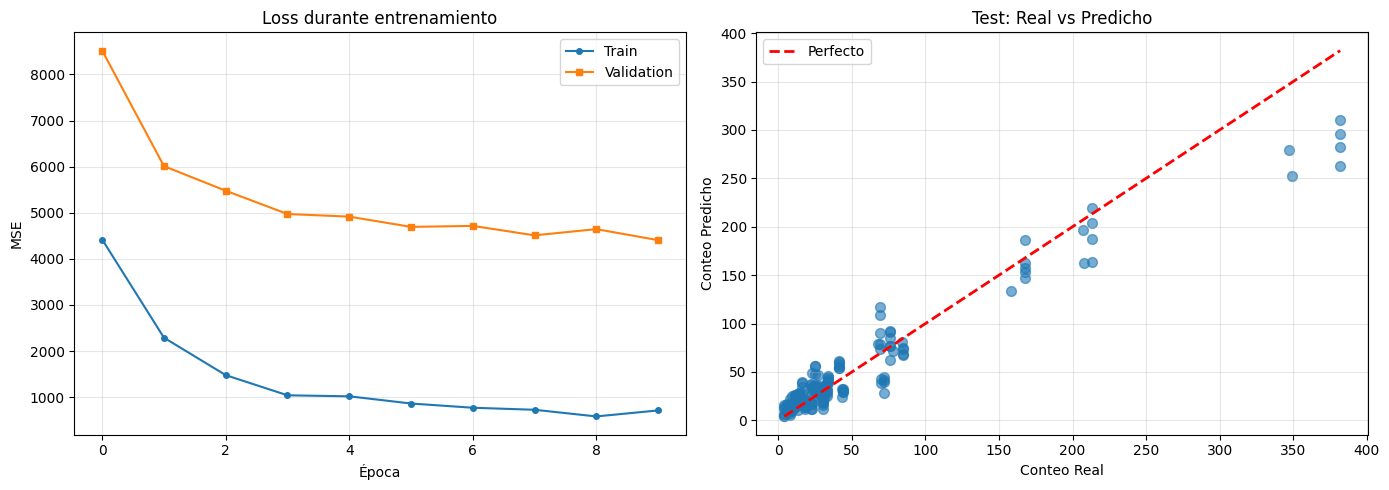

In [25]:
# VISUALIZACIÓN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train', marker='o', markersize=4)
axes[0].plot(history['val_loss'], label='Validation', marker='s', markersize=4)
axes[0].set_title('Loss durante entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, y_te_pred, alpha=0.6, s=50)
min_v = min(y_test.min(), y_te_pred.min())
max_v = max(y_test.max(), y_te_pred.max())
axes[1].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Perfecto')
axes[1].set_title('Test: Real vs Predicho')
axes[1].set_xlabel('Conteo Real')
axes[1].set_ylabel('Conteo Predicho')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
def build_resnet50_full(head_type='H1', backbone_cut='full'):
    model = models.resnet50(pretrained=True)
    
    if backbone_cut == 'sin_layer4':
        model.layer4 = nn.Identity()
        input_features = 1024
    else:
        input_features = 2048
    
    for p in model.parameters():
        p.requires_grad = False
    
    if head_type == 'H1':
        model.fc = nn.Sequential(nn.Linear(input_features, 512), nn.ReLU(), nn.Linear(512, 1))
    elif head_type == 'H2':
        model.fc = nn.Sequential(nn.Linear(input_features, 512), nn.BatchNorm1d(512), 
                                 nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, 1))
    elif head_type == 'H3':
        model.fc = nn.Sequential(nn.Linear(input_features, 1024), nn.ReLU(), nn.Dropout(0.3),
                                 nn.Linear(1024, 256), nn.ReLU(), nn.Linear(256, 1))
    elif head_type == 'H4':
        model.fc = nn.Sequential(nn.Linear(input_features, 128), nn.ReLU(), nn.Linear(128, 1))
    
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return model, trainable

def set_finetune_strategy(model, strategy):
    for p in model.parameters():
        p.requires_grad = False
    model.fc.requires_grad_(True)
    if strategy == 'S2':
        model.layer4.requires_grad_(True)
    elif strategy == 'S3':
        model.layer3.requires_grad_(True)
        model.layer4.requires_grad_(True)
    elif strategy == 'S4':
        model.layer2.requires_grad_(True)
        model.layer3.requires_grad_(True)
        model.layer4.requires_grad_(True)
    elif strategy == 'S5':
        for p in model.parameters():
            p.requires_grad = True
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model_twophase(model, tr_loader, va_loader, strategy, phase1_epochs=10, lr1=1e-3, lr2=1e-4, max_phase2_epochs=50, device=DEVICE):
    criterion = nn.MSELoss()
    tr_losses, va_losses = [], []
    best_va_loss = float('inf')
    patience, patience_cnt = 10, 0
    best_state = None
    
    print(f'[FASE 1] {phase1_epochs} épocas, lr={lr1}')
    for epoch in range(phase1_epochs):
        model.train()
        tr_loss = 0
        with tqdm(tr_loader, desc=f'Ph1·Ep {epoch+1}/{phase1_epochs}', leave=False) as pbar:
            optimizer = optim.Adam(model.parameters(), lr=lr1)
            for X_b, y_b in pbar:
                X_b, y_b = X_b.to(device), y_b.to(device)
                y_pred = model(X_b)
                loss = criterion(y_pred, y_b)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                tr_loss += loss.item()
        tr_loss /= len(tr_loader)
        
        model.eval()
        va_loss = 0
        with torch.no_grad():
            for X_b, y_b in va_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                y_pred = model(X_b)
                loss = criterion(y_pred, y_b)
                va_loss += loss.item()
        va_loss /= len(va_loader)
        tr_losses.append(tr_loss)
        va_losses.append(va_loss)
        if va_loss < best_va_loss:
            best_va_loss = va_loss
            patience_cnt = 0
            best_state = copy.deepcopy(model.state_dict())
    
    print(f'[FASE 2] {strategy}, lr={lr2}, max {max_phase2_epochs} épocas')
    set_finetune_strategy(model, strategy)
    for epoch in range(max_phase2_epochs):
        model.train()
        tr_loss = 0
        with tqdm(tr_loader, desc=f'Ph2·Ep {epoch+1}', leave=False) as pbar:
            optimizer = optim.Adam(model.parameters(), lr=lr2, weight_decay=0)
            for X_b, y_b in pbar:
                X_b, y_b = X_b.to(device), y_b.to(device)
                y_pred = model(X_b)
                loss = criterion(y_pred, y_b)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                tr_loss += loss.item()
        tr_loss /= len(tr_loader)
        
        model.eval()
        va_loss = 0
        with torch.no_grad():
            for X_b, y_b in va_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                y_pred = model(X_b)
                loss = criterion(y_pred, y_b)
                va_loss += loss.item()
        va_loss /= len(va_loader)
        tr_losses.append(tr_loss)
        va_losses.append(va_loss)
        if va_loss < best_va_loss:
            best_va_loss = va_loss
            patience_cnt = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'Early stopping Fase 2 en época {epoch+1}')
                break
    
    model.load_state_dict(best_state)
    return model, {'train_loss': tr_losses, 'val_loss': va_losses}

In [28]:
print('='*70)
print('ETAPA 1 - ARQUITECTURA (P1) · 40 experimentos')
print('='*70 + '\n')

backbone_cuts = ['full', 'sin_layer4']
head_variants = ['H1', 'H2', 'H3', 'H4']
finetune_strats = ['S1', 'S2', 'S3', 'S4', 'S5']

print(f'Grilla: {len(backbone_cuts)} × {len(head_variants)} × {len(finetune_strats)} = {len(backbone_cuts)*len(head_variants)*len(finetune_strats)} experimentos\n')

experiment_grid = []
for bb_cut in backbone_cuts:
    for head in head_variants:
        for strategy in finetune_strats:
            experiment_grid.append({'backbone_cut': bb_cut, 'head_variant': head, 'finetune_strategy': strategy})

print(f'✓ Grilla lista: {len(experiment_grid)} combinaciones\n')

ETAPA 1 - ARQUITECTURA (P1) · 40 experimentos

Grilla: 2 × 4 × 5 = 40 experimentos

✓ Grilla lista: 40 combinaciones



In [37]:
import sys; print('copy' in sys.modules)

results_p1 = []
print(f'Ejecutando {len(experiment_grid)} experimentos...\n')

for idx, exp in enumerate(experiment_grid, 1):
    print(f"Exp {idx}/40 | {exp['backbone_cut']} + {exp['head_variant']} + {exp['finetune_strategy']}")
    
    try:
        model, n_params = build_resnet50_full(exp['head_variant'], exp['backbone_cut'])
        model = model.to(DEVICE)
        model, history = train_model_twophase(model, tr_loader, va_loader, 
                                             strategy=exp['finetune_strategy'],
                                             phase1_epochs=10, lr1=1e-3, lr2=1e-4,
                                             max_phase2_epochs=50, device=DEVICE)
        
        y_tr_pred = predict(model, tr_loader, DEVICE, '')
        y_va_pred = predict(model, va_loader, DEVICE, '')
        y_te_pred = predict(model, te_loader, DEVICE, '')
        
        m_tr = compute_metrics(y_train, y_tr_pred)
        m_va = compute_metrics(y_val, y_va_pred)
        m_te = compute_metrics(y_test, y_te_pred)
        
        result = {
            'exp_id': idx,
            'backbone_cut': exp['backbone_cut'],
            'head_variant': exp['head_variant'],
            'finetune_strategy': exp['finetune_strategy'],
            'n_params': n_params,
            'tr_mae': m_tr['MAE'], 'va_mae': m_va['MAE'], 'te_mae': m_te['MAE'],
            'tr_rmse': m_tr['RMSE'], 'va_rmse': m_va['RMSE'], 'te_rmse': m_te['RMSE'],
            'tr_r2': m_tr['R2'], 'va_r2': m_va['R2'], 'te_r2': m_te['R2']
        }
        results_p1.append(result)
        print(f"  ✓ Test MAE: {m_te['MAE']:.4f}\n")
    except Exception as e:
        print(f"  ✗ ERROR: {str(e)[:80]}\n")

print(f"{'='*70}\nETAPA 1 COMPLETADA: {len(results_p1)}/40 experimentos\n")

True
Ejecutando 40 experimentos...

Exp 1/40 | full + H1 + S1
[FASE 1] 10 épocas, lr=0.001


[FASE 2] S1, lr=0.0001, max 50 épocas


Early stopping Fase 2 en época 24


/Users/markito/Desktop/TA_ia_aplicada/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/markito/Desktop/TA_ia_aplicada/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  ✓ Test MAE: 14.8232

Exp 2/40 | full + H1 + S2
[FASE 1] 10 épocas, lr=0.001


...

Early stopping Fase 2 en época 17


/Users/markito/Desktop/TA_ia_aplicada/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/markito/Desktop/TA_ia_aplicada/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  ✓ Test MAE: 19.3254

Exp 13/40 | full + H3 + S3
[FASE 1] 10 épocas, lr=0.001


[FASE 2] S3, lr=0.0001, max 50 épocas


KeyboardInterrupt: 

In [ ]:
df_p1 = pd.DataFrame(results_p1)
df_display = df_p1[['exp_id', 'backbone_cut', 'head_variant', 'finetune_strategy', 'te_mae', 'te_rmse', 'te_r2']].sort_values('te_mae')
df_display.columns = ['Exp', 'Backbone', 'Head', 'Strategy', 'Test MAE', 'Test RMSE', 'Test R²']

print('='*70)
print('TOP 15 CONFIGURACIONES (por Test MAE)')
print('='*70 + '\n')
print(df_display.head(15).to_string(index=False))

mejor_idx = df_p1['te_mae'].idxmin()
mejor = df_p1.loc[mejor_idx]
mejora = ((baseline_mae_test - mejor['te_mae']) / baseline_mae_test * 100)

print(f"\n\nMEJOR CONFIG: {mejor['backbone_cut']} + {mejor['head_variant']} + {mejor['finetune_strategy']}")
print(f"Test MAE: {mejor['te_mae']:.4f} (baseline: {baseline_mae_test:.4f})")
print(f"Mejora: {mejora:+.1f}%\n")